In [ ]:
from itertools import cycle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, DistributedSampler
from torchvision import datasets, transforms
from model import LeNet5


tran = transforms.Compose((transforms.ToTensor(), transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))))
full_train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=tran)

train_size = int(0.8 * len(full_train_dataset))  # 80% for training
val_size = len(full_train_dataset) - train_size  # 20% for validation

train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

# dloader = DataLoader(train_dataset, 10000, shuffle=True, pin_memory=True)
# print(len(dloader))


In [ ]:
from distributed import distributed_learning

model = distributed_learning(train_dataset, 5, 2, 2, 500, torch.optim.Adam, {"lr": 0.01})

In [ ]:
from typing import Iterator
from torch.utils.data import Dataset

class SimpleNumberDataset(Dataset):
    def __init__(self):
        # Input data: numbers from 1 to 10
        self.data = torch.arange(100, dtype=torch.float32)
        self.labels = torch.arange(100, dtype=torch.long) 

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]


def shuffle_and_split(train_data, N, random_seed=None) -> list[Iterator[DataLoader]]:
    if random_seed is not None:
        random_seed = torch.Generator().manual_seed(random_seed)

    lengths = [len(train_data) // N] * N

    return [iter(DataLoader(subset, batch_size=1)) for subset in random_split(train_data, lengths, random_seed)]

d = SimpleNumberDataset()

a = shuffle_and_split(d, 5)



In [ ]:
import experiments_config
from functools import partial
import os
import time
import ray
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split
from ray import tune
from ray.tune import CLIReporter
# from ray.tune.search.variant_generator import BasicVariantGenerator

from distributed import distributed_learning
from hyperparameter import custom_trial_name, tune_distributed_learning
from model import evaluate_model, load_data
import experiments_config


search_space = experiments_config.play_araound

experment_folder = os.path.join(os.path.abspath("ray_results"), f"play_arr")

train_dataset, val_dataset = load_data()

ray.init()
train_data_obj_ref = ray.put((train_dataset, val_dataset))

reporter = CLIReporter(metric_columns=["val_loss", "val_acc"])

print("Cuda available:", torch.cuda.is_available())

analysis = tune.run(
    partial(tune_distributed_learning, train_data_obj_ref=train_data_obj_ref),
    config=search_space,
    num_samples=2,
    progress_reporter=reporter,
    storage_path=experment_folder,
    max_concurrent_trials=1,
    trial_name_creator=custom_trial_name,
    trial_dirname_creator=lambda t: f"trial_{t.trial_id}",
    metric="val_acc",
    mode="max"
)
print("Best hyperparameters found: ", analysis.best_config)
print("Best validation accuracy: ", analysis.best_result)

analysis.results_df.to_csv(os.path.join(experment_folder, "playy_arrsas_ress.csv"))


In [ ]:
import json
import pandas as pd
import os
def gen_dataframe(s):
    l = []
    for folder in os.listdir(s):
        folder = os.path.join(s, folder)
        if os.path.isdir(folder):
            with open(os.path.join(folder, "result.json"), "r") as f:
                res = json.load(f)

            res.pop("config")
            with open(os.path.join(folder, "params.json"), "r") as f:
                params = json.load(f)
            
            for k, v in params.items():
                res[f"config/{k}"] = v

            l.append(res)
    df = pd.DataFrame(l)
    # df.to_pickle(os.path.join(s, "analysis_results.pkl"))
    return df
    

df = gen_dataframe("ray_results\\mini_batch_sgd_2025-01-03_11-45-52")

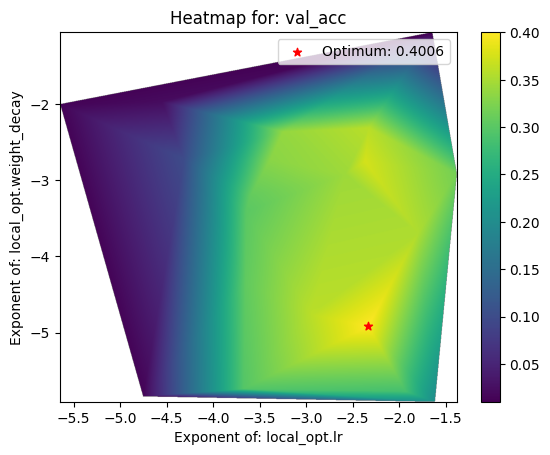

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

def hyper_params_heatmap(results, param_1_name, param_2_name, val_name, log_scale_1=True, log_scale_2=True):
    x = results[f"config/{param_1_name}"]
    y = results[f"config/{param_2_name}"]

    if log_scale_1:
        x = np.log10(x)
        param_1_name = "Exponent of: " + param_1_name
    if log_scale_2:
        y = np.log10(y)
        param_2_name = "Exponent of: " + param_2_name

    val = results[val_name]

    inter = LinearNDInterpolator((x, y), val)

    x_int = np.linspace(x.min(), x.max(), 1000)
    y_int = np.linspace(y.min(), y.max(), 1000)
    mesh = np.meshgrid(x_int, y_int)
    inter_val = inter(mesh)

    plt.imshow(inter_val, extent=[x_int[0], x_int[-1], y_int[0], y_int[-1]], origin="lower", aspect="auto")
    plt.colorbar()
    plt.scatter(x[np.argmax(val)], y[np.argmax(val)], c="r", marker="*", label=f"Optimum: {np.max(val)}")
    plt.xlabel(param_1_name)
    plt.ylabel(param_2_name)
    plt.title(f"Heatmap for: {val_name}")
    plt.legend()



hyper_params_heatmap(df, "local_opt.lr", "local_opt.weight_decay", "val_acc", True, True)



In [50]:
df.filter(["config/local_opt.lr", "config/local_opt.weight_decay", "val_acc"])

,config/local_opt.lr,config/local_opt.weight_decay,val_acc
0,0.000225,0.000389,0.3007
1,0.000406,0.001865,0.3317
2,0.015850,0.000203,0.3528
3,0.024025,0.000001,0.2026
4,0.004622,0.000012,0.4006
5,0.011705,0.000002,0.2851
6,0.000018,0.000001,0.0142
7,0.000561,0.004329,0.3380
8,0.001134,0.000017,0.3598
9,0.000211,0.000002,0.2966


In [ ]:
import seaborn as sns


sns.heatmap()

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric, **kwargs):
    plt.plot(range(len(metric)), metric, **kwargs)
    plt.xlabel("Epochs")
    plt.grid(True)


plot_metric(train_loss, marker="x")
plot_metric(eval_loss)
plt.ylabel("Loss")

In [ ]:
for i in range(5, 15):
    print(2**i)